### Imports

In [1]:
import pycmap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Query

In [ ]:
api = pycmap.API(token='<YOUR TOKEN HERE>') # ADD API KEY HERE

# Table Names
tables = [
    'tblL4_phytoplankt_nanoflagellates_bacteria_2007',
    'tblL4_phytoplankt_nanoflagellates_bacteria_2008',
    'tblL4_phytoplankt_nanoflagellates_bacteria_2009',
    'tblL4_phytoplankt_nanoflagellates_bacteria_2010',
    'tblL4_phytoplankt_nanoflagellates_bacteria_2011',
]

dfs = [api.get_dataset(tbl) for tbl in tables]
df = pd.concat(dfs, ignore_index=True)
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values(['time', 'depth']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Time range: {df['time'].min()} to {df['time'].max()}")
print(f"Unique time points: {df['time'].nunique()}")
print(f"Columns: {list(df.columns)}")

/opt/homebrew/Caskroom/miniforge/base/envs/tf-workshop/lib/python3.10/site-packages/pycmap/rest.py:334: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json(df['JSON_stats'][0])
/opt/homebrew/Caskroom/miniforge/base/envs/tf-workshop/lib/python3.10/site-packages/pycmap/rest.py:335: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  rows = int(df.loc[['count'], 'lat'])
/opt/homebrew/Caskroom/miniforge/base/envs/tf-workshop/lib/python3.10/site-packages/pycmap/rest.py:334: FutureWarning: Passing literal json to 'read_json' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_json(df['JSON_stats'][0])
/opt/homebrew/Caskroom/miniforge/base/envs/tf-workshop/lib/python3.10/site-packages/pycmap

Shape: (681, 24)
Time range: 2007-04-23 00:00:00 to 2011-12-19 00:00:00
Unique time points: 177
Columns: ['time', 'lat', 'lon', 'depth', 'synechococcus_spp', 'synechococcus_spp_std_dev', 'peuk', 'peuk_std_dev', 'neuk', 'neuk_std_dev', 'coccolith', 'coccolith_std_dev', 'cryptophyta', 'cryptophyta_std_dev', 'phaeocystis_sp', 'phaeocystis_sp_std_dev', 'dinofl', 'dinofl_std_dev', 'hneuk', 'hneuk_std_dev', 'hna_het', 'hna_het_std_dev', 'lna', 'lna_std_dev']


### Depth distribution and missingness

In [3]:
# How many samples at each depth?
print("Samples per depth:")
print(df.groupby('depth').size().sort_index())

print(f"\nMissing data (%):")
print((df.isna().sum() / len(df) * 100).round(1).sort_values(ascending=False))

Samples per depth:
depth
0.2     173
1.0       4
4.0       1
4.5       1
5.0       2
6.0       2
6.5       1
7.0       5
7.5       3
8.0       3
8.5       3
9.0       2
9.5       2
10.0    129
11.0      6
12.0      3
13.0      8
16.0      2
25.0    166
48.0      2
50.0    158
51.0      2
52.0      2
53.0      1
dtype: int64

Missing data (%):
hneuk_std_dev                8.1
hneuk                        7.0
hna_het_std_dev              2.6
lna_std_dev                  2.3
lna                          0.7
hna_het                      0.7
peuk_std_dev                 0.4
synechococcus_spp_std_dev    0.3
peuk                         0.3
neuk_std_dev                 0.3
coccolith_std_dev            0.3
cryptophyta_std_dev          0.1
cryptophyta                  0.1
coccolith                    0.1
neuk                         0.1
synechococcus_spp            0.1
lat                          0.0
phaeocystis_sp               0.0
phaeocystis_sp_std_dev       0.0
dinofl                      

### Save the full dataset

In [ ]:
# df.to_csv('../data/hackathon_data/l4_plankton_community.csv', index=False)
# print(f"Saved: {df.shape}")
# print("Saved to ../data/hackathon_data/l4_plankton_community.csv")

Saved: (681, 24)
Saved to l4_plankton_community.csv


### Plot all data colored by depth

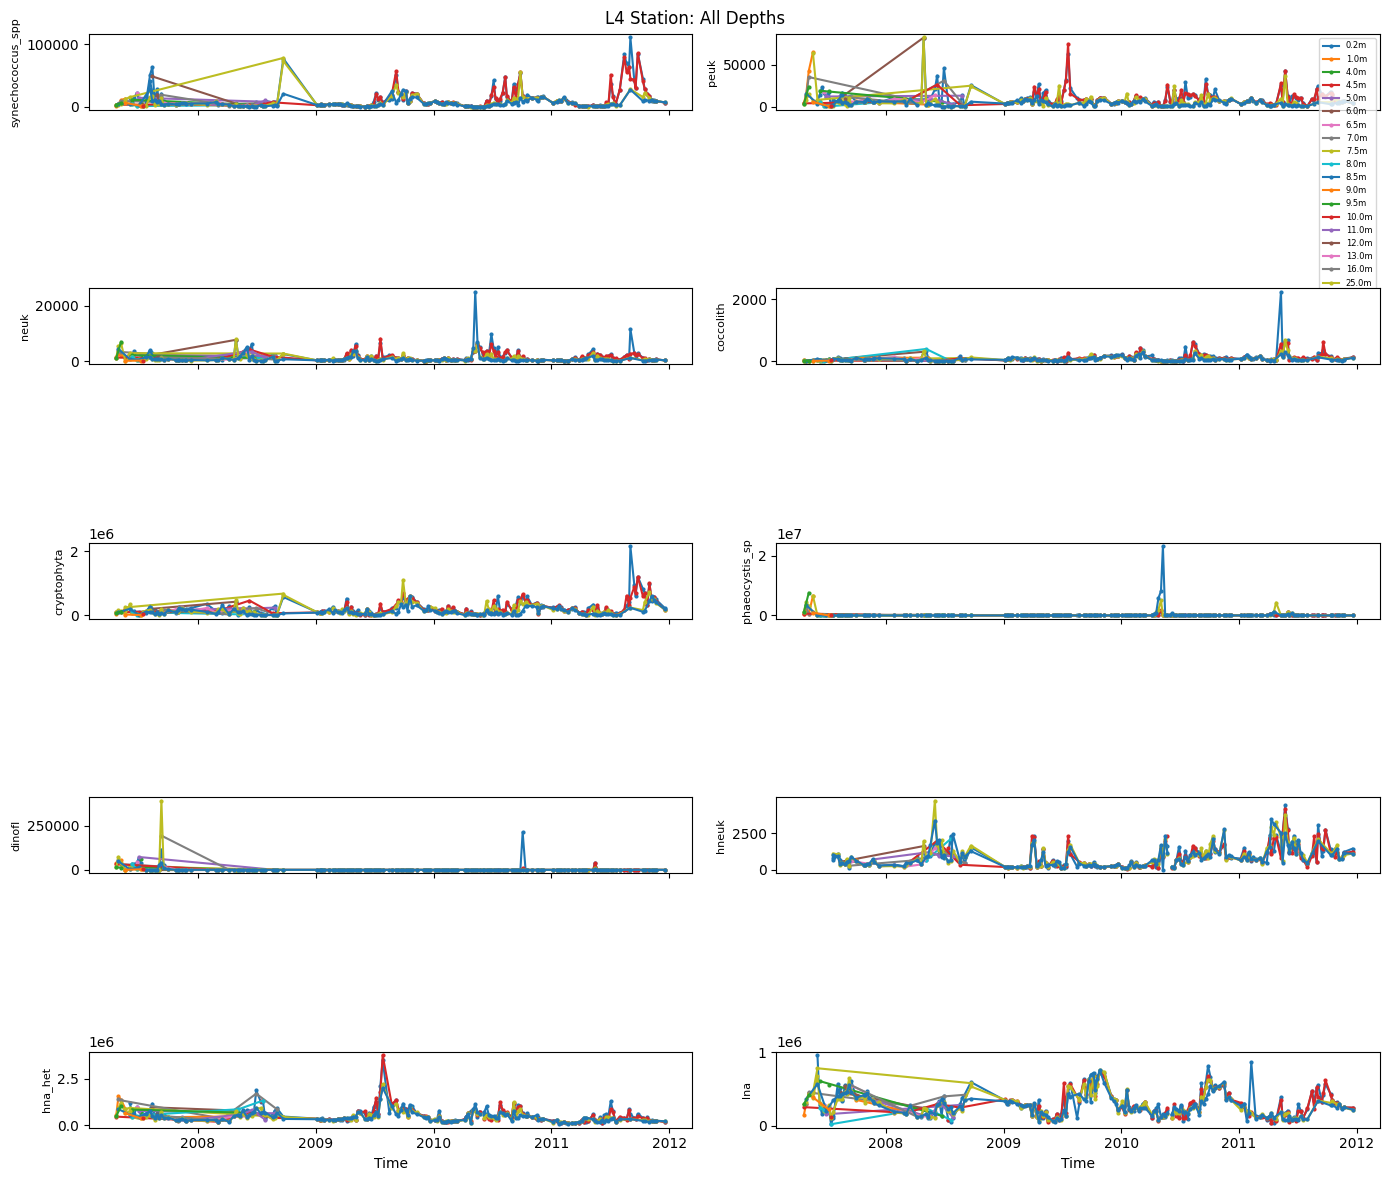

In [5]:
sci_cols = ['synechococcus_spp', 'peuk', 'neuk', 'coccolith', 'cryptophyta',
            'phaeocystis_sp', 'dinofl', 'hneuk', 'hna_het', 'lna']

fig, axs = plt.subplots(5, 2, figsize=(14, 12), sharex=True)
for ax, col in zip(axs.flat, sci_cols):
    for d, grp in df.groupby('depth'):
        ax.plot(grp['time'], grp[col], 'o-', ms=2, label=f'{d}m')
    ax.set_ylabel(col, fontsize=8)
axs[0, 1].legend(fontsize=6, loc='upper right')
axs[-1, 0].set_xlabel('Time')
axs[-1, 1].set_xlabel('Time')
fig.suptitle('L4 Station: All Depths', fontsize=12)
plt.tight_layout()
plt.savefig('l4_all_depths_timeseries.png', dpi=150)
plt.show()

### Filter to well-sampled depths and plot

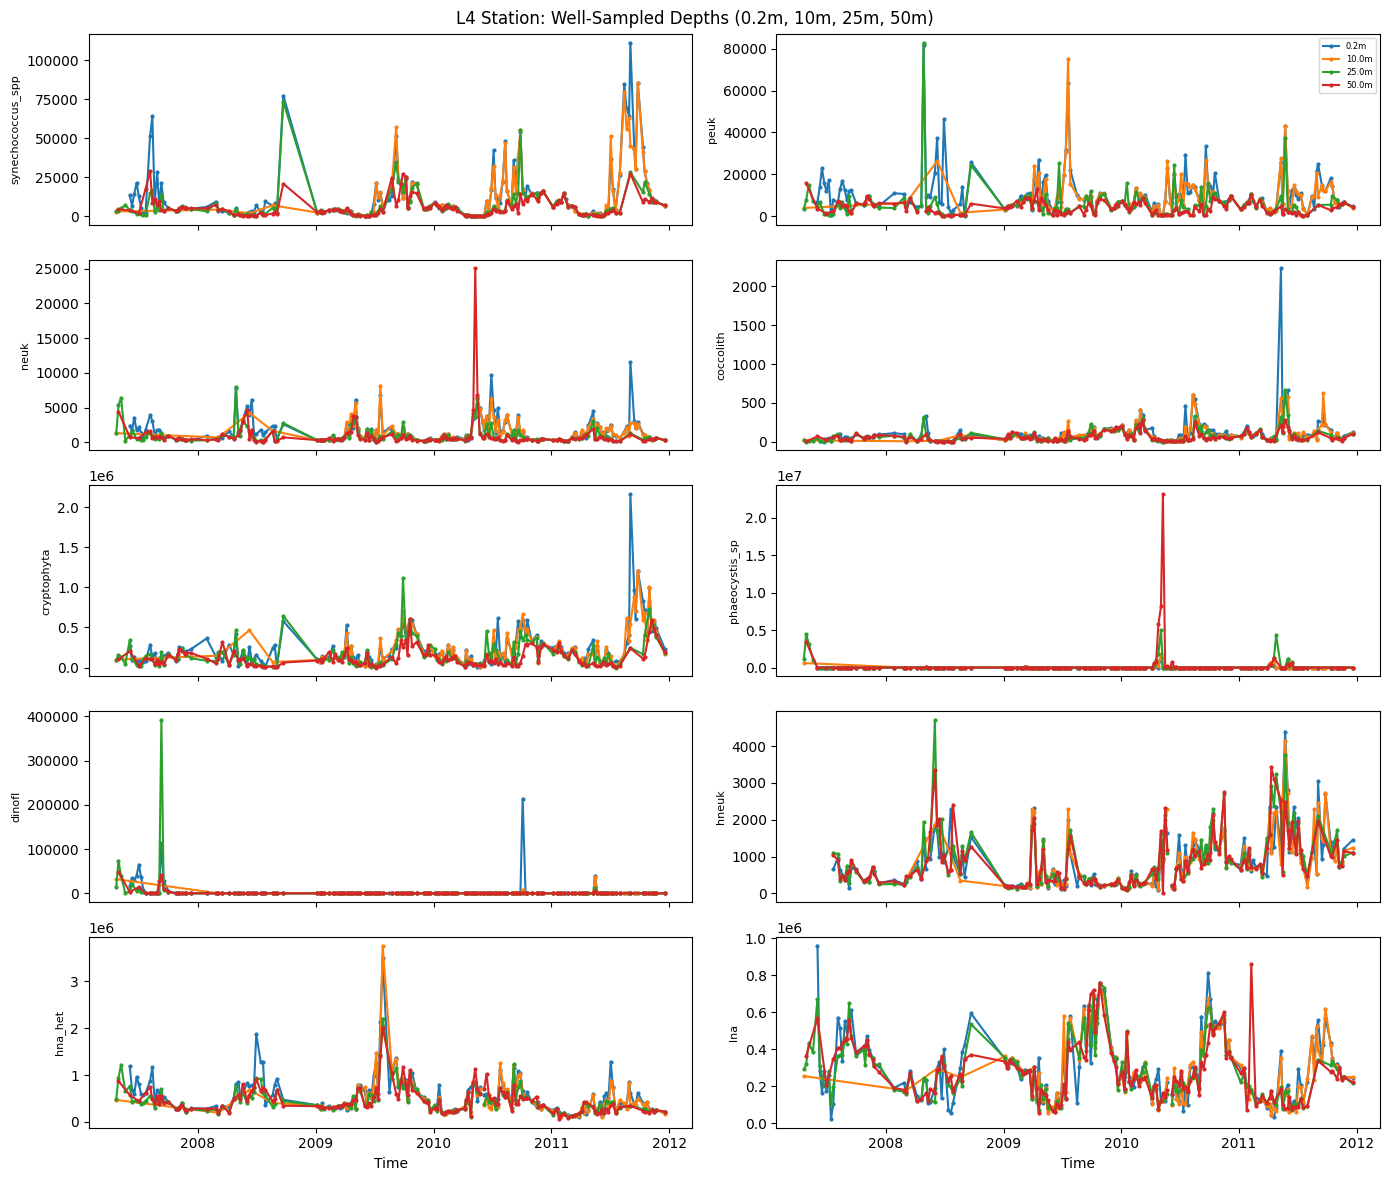

In [6]:
good_depths = [0.2, 10.0, 25.0, 50.0] # Based on data availability
df_filt = df[df['depth'].isin(good_depths)].copy()

fig, axs = plt.subplots(5, 2, figsize=(14, 12), sharex=True)
for ax, col in zip(axs.flat, sci_cols):
    for d, grp in df_filt.groupby('depth'):
        ax.plot(grp['time'], grp[col], 'o-', ms=2, label=f'{d}m')
    ax.set_ylabel(col, fontsize=8)
axs[0, 1].legend(fontsize=6, loc='upper right')
axs[-1, 0].set_xlabel('Time')
axs[-1, 1].set_xlabel('Time')
fig.suptitle('L4 Station: Well-Sampled Depths (0.2m, 10m, 25m, 50m)', fontsize=12)
plt.tight_layout()
plt.savefig('l4_filtered_depths_timeseries.png', dpi=150)
plt.show()